<a href="https://colab.research.google.com/github/FRA-0023/Business_Game_JEMIB/blob/main/notebooks/sangiovese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Structural Modeling in Viticulture
## Counterfactual Evaluation of Canopy Management for *Vitis vinifera* L. cv. Sangiovese

**Candidate**: Colombini Francesco   
**Reference**: Magrini, Di Blasi & Stefanini (2017). *Biometrical Letters* 54.1, pp. 25–42.

---

## 1. Introduction and Research Framework

### 1.1 Objective

The goal of this project is to apply causal inference to measure how specific canopy management choices **bud load**, **defoliation**, and **cluster thinning** together with **harvest timing** actually change the physico-chemical quality of Sangiovese musts.

The dataset comes from a $2^4$ factorial experiment run over multiple vintages at two Tuscan vineyards (Magrini et al., 2017), giving **16 experimental treatments** (T1a–T8b). The causal model is a **Conditional Linear Gaussian Network (CLGN)** parametrised by a coefficient matrix $B$ and a residual covariance $\Sigma$; the graph topology is in `sangiovese.gml` and the parameters are re-estimated from `sangiovese.csv`.

### 1.2 Treatment Comparison

All queries compare **T4a** against the reference **T1a**:

| Code | Buds | Defoliation | Bunch Thinning | Harvest |
|------|------|-------------|----------------|---------|
| **T1a** (reference) | Low | None | None | Technological |
| **T4a** (active)    | Low | 50%  | 50%  | Technological |

Both treatments share bud load and harvest time; T4a adds full defoliation and cluster thinning, making it the most intensive canopy intervention in the low-bud, technological-harvest group.

---
## 2. Theoretical Framework

### 2.1 Structural Causal Models

Following Pearl (2009), a **Structural Causal Model (SCM)** $\mathcal{M}$ is a 4-tuple $\langle \mathbf{U}, \mathbf{V}, \mathcal{F}, P(\mathbf{U}) \rangle$ where:

- $\mathbf{U}$ are **exogenous** variables all sources of randomness outside the system;
- $\mathbf{V}$ are **endogenous** variables whose values the model determines;
- $\mathcal{F}$ is a set of **structural equations** $V_j := f_j(\mathbf{Pa}_j, U_j)$, where $\mathbf{Pa}_j$ are the direct causes of $V_j$.

The `:=` notation is deliberate: a structural equation is a **causal mechanism**, not just a statistical association. The SCM induces a **DAG** $\mathcal{G}$ by placing an edge $V_k \to V_j$ whenever $V_k \in \mathbf{Pa}_j$. Acyclicity ensures a consistent recursive solution for any realization of $\mathbf{U}$.

---

### 2.2 The Conditional Linear Gaussian Network (CLGN)

A **CLGN** (Lauritzen & Wermuth, 1989) is an SCM where every structural equation is **linear** and every noise term is **Gaussian**. It mixes one or more **categorical** root nodes (here: *Treatment*, 16 levels) with $p$ **continuous** outcome nodes.

#### 2.2.1 Node-level Structural Equations

For each continuous node $j$:

$$x_j := \alpha_j + \sum_{k \in \mathbf{Pa}_j^c} b_{jk}\, x_k + \gamma_{j,t}\, \mathbf{1}[\text{Treatment} \in \mathbf{Pa}_j] + u_j$$

where $x_j = \log V_j$ is the log-transformed measurement (annual means subtracted to remove vintage heterogeneity), $b_{jk}$ is the structural coefficient of parent $k$ on child $j$, $\gamma_{j,t}$ is the treatment-specific intercept shift (zero for T1a), and $u_j \sim \mathcal{N}(0, \sigma_j^2)$ with $u_j \perp u_k$ for $j \neq k$.

#### 2.2.2 Matrix Form

Stacking all $p$ equations:

$$\mathbf{x} = B^\top \mathbf{x} + \boldsymbol{\alpha} + C\,\mathbf{d}_t + \mathbf{u}$$

- $B$ ($p\times p$): structural coefficient matrix, $B_{kj} = b_{jk}$;
- $C$ ($p\times K$): treatment coefficient matrix;
- $\mathbf{d}_t$: one-hot treatment dummy (zero for T1a);
- $\Sigma = \mathrm{diag}(\sigma_1^2,\ldots,\sigma_p^2)$: diagonal residual covariance.

Because $\mathcal{G}$ is a DAG, nodes can be topologically sorted so that $B$ is **strictly lower-triangular**, which guarantees $\det(I-B^\top)=1 \neq 0$ regardless of the coefficient values.

#### 2.2.3 Closed-Form Joint Distribution

Since $(I-B^\top)$ is always invertible, the system has a unique solution:

$$\boxed{\boldsymbol{\mu}(t) = \mathbb{E}[\mathbf{x}\mid T{=}t] = (I-B^\top)^{-1}(\boldsymbol{\alpha} + C\,\mathbf{d}_t)}$$

$$\boxed{\Omega = \mathrm{Cov}(\mathbf{x}\mid T{=}t) = (I-B^\top)^{-1}\,\Sigma\,(I-B^\top)^{-\top}}$$

Note that $\Omega$ does not depend on $t$: treatment only shifts the mean, not the covariance. The full conditional is $\mathbf{x}\mid T{=}t \sim \mathcal{N}(\boldsymbol{\mu}(t), \Omega)$.

---

### 2.3 Fitting Strategy: OLS per Node as Exact MLE

Since $\Sigma$ is diagonal and the equations are recursive, the joint log-likelihood factorises node by node:

$$\ell(B,\boldsymbol{\alpha},C,\Sigma) = \sum_{j=1}^p \ell_j(\boldsymbol{\beta}_j, \sigma_j^2)$$

Each term involves only node $j$'s parameters, so maximising them independently gives the exact global MLE: **OLS per node**. This is not an approximation it follows directly from the triangular structure of $B$ and the independence of the noise terms.

---

### 2.4 The Three Layers of Causal Inference

Pearl's **Ladder of Causation** organises causal questions by what they require:

| Rung | Name | Operation | Example here |
|------|------|-----------|-------------|
| **1** | Association | $P(Y\mid X=x)$ | Average Anthoc for vines receiving T4a |
| **2** | Intervention | $P(Y\mid do(X=x))$ | Anthoc if we *force* every vine to T4a |
| **3** | Counterfactual | $P(Y_x\mid X=x')$ | What Anthoc *would have been* under T4a for a vine that got T1a |

Rungs 1 and 2 coincide here because Treatment has no parents. Rung 3 is required for Q3–Q6 (NDE and NIE), which involve reasoning about a unit simultaneously under two treatment states.

---

### 2.5 Rung-2: Interventional Distributions via the *do*-Operator

An intervention $do(T=t)$ surgically removes all edges into $T$ in $\mathcal{G}$ and clamps $T:=t$. Since Treatment is already a root node here (no parents), this changes nothing structurally:

$$P(\mathbf{x}\mid do(T{=}t)) = P(\mathbf{x}\mid T{=}t)$$

Intervention and conditioning are equivalent, so **no back-door or front-door adjustment is needed** the treatment mean vector $\boldsymbol{\mu}(t)$ directly gives $\mathbb{E}[\mathbf{x}\mid do(T{=}t)]$.

---

### 2.6 Rung-3: Counterfactuals via Abduction–Action–Prediction

NDE and NIE (Q3–Q6) require cross-world reasoning: imagining the same unit under two treatment states simultaneously. Pearl (2009) handles this through three steps:

1. **Abduction** infer the posterior over exogenous noise $\mathbf{U}$ given the    observed data. At the population level this averages over $P(\mathbf{U})$.
2. **Action** modify the SCM by clamping Treatment (or a mediator) to a fixed value.
3. **Prediction** propagate the posterior noise through the modified SCM.

For population-level expectations in a linear-Gaussian model, the noise averages out and Steps 2–3 reduce to evaluating $\boldsymbol{\mu}(t)$ on the modified (frozen) system exactly what `mu_propagate(treatment, frozen={...})` does.

---

### 2.7 Mediation Analysis: NDE, NIE, and TE = NDE + NIE

Let $M$ be a mediator and $Y$ an outcome. Comparing T4a against T1a:

$$\text{TE} = \mathbb{E}[x_j(T4a)] - \mathbb{E}[x_j(T1a)]$$

$$\text{NDE} = \mathbb{E}[x_j(T4a, M(T1a))] - \mathbb{E}[x_j(T1a, M(T1a))]$$

$$\text{NIE} = \mathbb{E}[x_j(T1a, M(T4a))] - \mathbb{E}[x_j(T1a, M(T1a))]$$

Under a linear model (no treatment–mediator interaction):

$$\boxed{\text{TE} = \text{NDE} + \text{NIE}}$$

This holds **exactly** and is verified numerically in Section 5.5.

Identification holds under three assumptions all satisfied here because Treatment is randomised and $\Sigma$ is diagonal (no unmeasured confounding between any pair of nodes):

1. No unmeasured confounders between $T$ and $Y$.
2. No unmeasured confounders between $M$ and $Y$.
3. No unmeasured confounders between $T$ and $M$.


---
## 3. Causal Queries: Definitions and Identification

All effects are defined using potential-outcome notation: $x_j(t)$ is the value node $j$ would take under $do(T{=}t)$, and $x_M(t)$ is the value mediator $M$ would take under $do(T{=}t)$. In matrix terms, $\boldsymbol{\mu}(t) = (I-B^\top)^{-1}(\boldsymbol{\alpha}+C\mathbf{d}_t)$.

**Total Effect (TE):** $\mathbb{E}[x_j(T4a)] - \mathbb{E}[x_j(T1a)]$ effect through all paths.

**NDE:** $\mathbb{E}[x_j(T4a, M(T1a))] - \mathbb{E}[x_j(T1a, M(T1a))]$ effect through paths that bypass $M$ (implemented by freezing $M$ at $\mu_M(T1a)$).

**NIE:** $\mathbb{E}[x_j(T1a, M(T4a))] - \mathbb{E}[x_j(T1a, M(T1a))]$ effect carried exclusively through $M$ (T stays at T1a, $M$ moves to $\mu_M(T4a)$).

Under the linear model: $\mathbf{TE} = \mathbf{NDE} + \mathbf{NIE}$ exactly.

---

### 3.1 Q1 Total Effect on Anthocyanin

$$Q_1 = \mathbb{E}[\text{Anthoc}(T4a)] - \mathbb{E}[\text{Anthoc}(T1a)]$$

*How much does total anthocyanin content change when every vine receives T4a rather than T1a, with all causal pathways free to operate?*

This is a Rung-2 query. Since Treatment is a root node, no back-door adjustment is needed. The effect accumulates through all paths from Treatment to Anthoc: Treatment → BunchN → Anthoc, Treatment → SproutN → BunchN → WoodW → Anthoc, and Treatment → SproutN → NDVI08 → Anthoc.

---

### 3.2 Q2 Total Effect on Potential Alcohol

$$Q_2 = \mathbb{E}[\text{Brix}(T4a)] - \mathbb{E}[\text{Brix}(T1a)]$$

*How much does potential alcohol change under T4a versus T1a, through all mechanisms?*

Treatment is a direct parent of Brix; Anthoc is its only continuous parent, so the TE mixes a direct path (Treatment → Brix) and an indirect one (Treatment → … → Anthoc → Brix). Identification is identical to Q1.

---

### 3.3 Q3 NDE on Polyphenols (mediator: BunchN)

$$Q_3 = \mathbb{E}[\text{Polyph}(T4a,\,\text{BunchN}(T1a))] - \mathbb{E}[\text{Polyph}(T1a,\,\text{BunchN}(T1a))]$$

*How much does polyphenol content change under T4a when bunch number is kept at its T1a level? This isolates the part of T4a's effect that does not flow through yield reduction.*

Identified by the mediation formula under the three assumptions in Section 2.7. In practice: zero the BunchN column of $B$ and inject $\mu_{\text{BunchN}}(T1a)$ as a fixed offset before propagating the remaining equations.

---

### 3.4 Q4 NDE on Polyphenols (mediator: Anthoc)

$$Q_4 = \mathbb{E}[\text{Polyph}(T4a,\,\text{Anthoc}(T1a))] - \mathbb{E}[\text{Polyph}(T1a,\,\text{Anthoc}(T1a))]$$

*How much does polyphenol content change under T4a when anthocyanin is frozen at its T1a level? This blocks the dominant Anthoc → Polyph edge and shows what remains of T4a's effect without the pigment pathway.*

Identification is the same as Q3, with Anthoc as the frozen mediator.

---

### 3.5 Q5 NIE on pH (mediator: BunchN)

$$Q_5 = \mathbb{E}[\text{pH}(T1a,\,\text{BunchN}(T4a))] - \mathbb{E}[\text{pH}(T1a,\,\text{BunchN}(T1a))]$$

*How much of the T4a-induced change in pH is attributable solely to the change in bunch number? Treatment stays at T1a everywhere; only BunchN moves to its T4a level.*

This isolates the path BunchN → Acid → pH and is identified by the same mediation formula.

---

### 3.6 Q6 NIE on Grape Weight (mediator: Anthoc)

$$Q_6 = \mathbb{E}[\text{GrapeW}(T1a,\,\text{Anthoc}(T4a))] - \mathbb{E}[\text{GrapeW}(T1a,\,\text{Anthoc}(T1a))]$$

*By how much does grape weight change when only Anthoc moves to its T4a level, with everything else at T1a? This captures the pigmentation-driven component of berry-size reduction, isolated from yield compression.*

Identification is the same as Q5, with Anthoc as the moving mediator.


---
## 4. Computational Implementation

### 4.1 Environment Setup

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import statsmodels.formula.api as smf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

# constants used throughout the notebook
TREATMENTS = [
    "T1a", "T1b", "T2a", "T2b", "T3a", "T3b", "T4a", "T4b",
    "T5a", "T5b", "T6a", "T6b", "T7a", "T7b", "T8a", "T8b"
]
CONTINUOUS = [
    "SproutN", "BunchN", "GrapeW", "WoodW",
    "SPAD06", "NDVI06", "SPAD08", "NDVI08",
    "Acid", "Potass", "Brix", "pH", "Anthoc", "Polyph"
]

TREATMENT_NODE = "Treatment"
T_REF, T_ACT  = "T1a", "T4a"

print("Environment ready.")

Environment ready.


### 4.2 Load the Causal Graph

Nodes (15): ['Acid', 'Anthoc', 'Brix', 'BunchN', 'GrapeW', 'NDVI06', 'NDVI08', 'Polyph', 'Potass', 'SPAD06', 'SPAD08', 'SproutN', 'Treatment', 'WoodW', 'pH']

Edges (55):
  Acid → GrapeW
  Acid → pH
  Anthoc → Acid
  Anthoc → Brix
  Anthoc → GrapeW
  Anthoc → Polyph
  Anthoc → Potass
  Anthoc → pH
  Brix → Acid
  Brix → GrapeW
  Brix → Polyph
  Brix → pH
  BunchN → Acid
  BunchN → Anthoc
  BunchN → GrapeW
  BunchN → Polyph
  BunchN → Potass
  BunchN → WoodW
  NDVI06 → Acid
  NDVI06 → GrapeW
  NDVI06 → NDVI08
  NDVI06 → Polyph
  NDVI06 → SPAD08
  NDVI08 → Acid
  NDVI08 → Anthoc
  NDVI08 → GrapeW
  NDVI08 → Polyph
  NDVI08 → WoodW
  Polyph → Acid
  Polyph → pH
  Potass → pH
  SPAD06 → Acid
  SPAD06 → NDVI06
  SPAD06 → Potass
  SPAD06 → SPAD08
  SPAD06 → WoodW
  SPAD06 → pH
  SPAD08 → NDVI08
  SPAD08 → WoodW
  SproutN → Acid
  SproutN → BunchN
  SproutN → GrapeW
  SproutN → NDVI06
  SproutN → NDVI08
  SproutN → SPAD06
  SproutN → WoodW
  SproutN → pH
  Treatment → Brix
  Treatment → Bunch

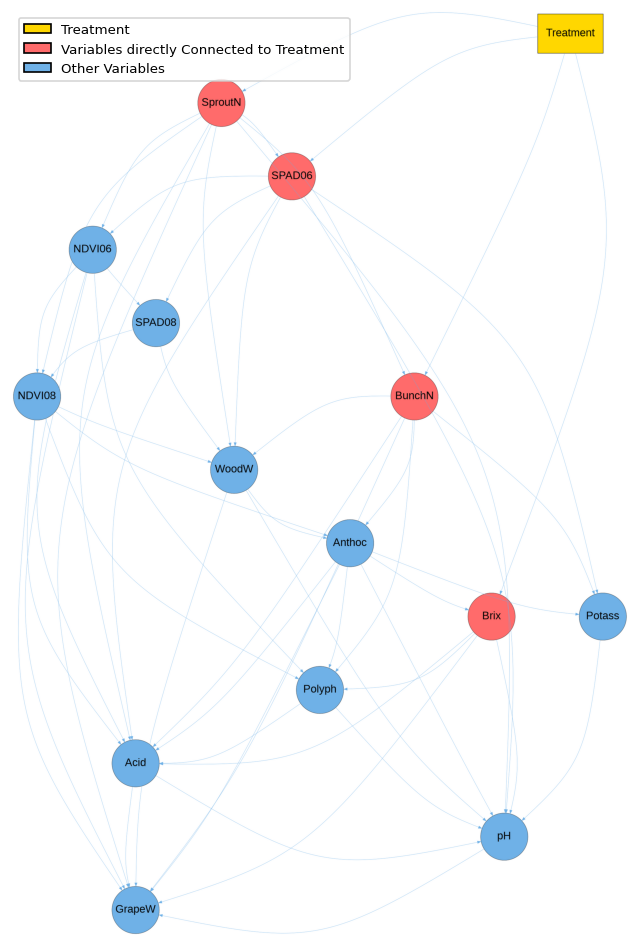

In [4]:
import networkx as nx
from networkx.drawing.nx_pydot import to_pydot
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from io import BytesIO

G = nx.read_gml("sangiovese.gml")
if not G.is_directed(): G = G.to_directed()
TREATMENT_NODE = "Treatment"

# direct children of Treatment in the DAG
treatment_neighbors = set()
if TREATMENT_NODE in G.nodes():
    treatment_neighbors = set(G.successors(TREATMENT_NODE)) | set(G.predecessors(TREATMENT_NODE))

P = to_pydot(G)

assert nx.is_directed_acyclic_graph(G), "Graph must be a DAG"

# make sure the label in the graph matches our constant
if 'Treatment' in G.nodes():
    G = nx.relabel_nodes(G, {'Treatment': TREATMENT_NODE})

# topological order needed for forward propagation later
TOPO = list(nx.topological_sort(G))
# drop Treatment; it's categorical, not continuous
CONT_TOPO = [n for n in TOPO if n != TREATMENT_NODE]

print(f"Nodes ({len(G.nodes())}): {sorted(G.nodes())}")
print(f"\nEdges ({len(G.edges())}):")
for u, v in sorted(G.edges()):
    print(f"  {u} → {v}")
print(f"\nTopological order: {TOPO}")

# graph layout and styling
P.set("splines", "curved")
P.set("overlap", "false")
P.set("rankdir", "TB")
P.set("nodesep", "0.8")
P.set("ranksep", "1.0")

# font settings shared across the plot
FONTNAME = "Helvetica"
FONTSIZE = "30"
BIG_NODE_WH = "1.8"
BIG_TREAT_WH = ("2.5", "1.5")

# colour scheme
COLOR_TREATMENT = "#FFD700"
COLOR_CONNECTED = "#FF6B6B"  # red for direct connections
COLOR_DEFAULT = "#6FB1E7"    # blue for others

for n in P.get_nodes():
    node_name = n.get_name().strip('"')

    n.set("penwidth", "0.4")
    n.set("fixedsize", "true")
    n.set("width", BIG_NODE_WH)
    n.set("height", BIG_NODE_WH)
    n.set("margin", "0.06")
    n.set("fontsize", FONTSIZE)
    n.set("fontname", FONTNAME)
    n.set("penwidth", "0.6")
    n.set("shape", "circle")
    n.set("style", "filled")
    n.set("color", "black")

    # Color based on node type
    if node_name == TREATMENT_NODE:
        n.set("shape", "box")
        n.set("fillcolor", COLOR_TREATMENT)
        n.set("penwidth", "1.0")
        n.set("width", BIG_TREAT_WH[0])
        n.set("height", BIG_TREAT_WH[1])
    elif node_name in treatment_neighbors:
        n.set("fillcolor", COLOR_CONNECTED)
    else:
        n.set("fillcolor", COLOR_DEFAULT)

for e in P.get_edges():
    e.set("penwidth", "0.6")
    e.set("color", "#6FB1E7")

# draw the graph
png = P.create(prog="dot", format="png")
img = Image.open(BytesIO(png))
img = img.resize((int(img.width*1.6), int(img.height*1.6)), Image.LANCZOS)

# add a legend to distinguish node types
fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img)
ax.axis("off")

# attach the legend
legend_elements = [
    Patch(facecolor=COLOR_TREATMENT, edgecolor='black', label='Treatment'),
    Patch(facecolor=COLOR_CONNECTED, edgecolor='black', label='Variables directly Connected to Treatment'),
    Patch(facecolor=COLOR_DEFAULT, edgecolor='black', label='Other Variables')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.show()


The graph is drawn in topological layers: Treatment at the top as the root, then the vegetative nodes, and the quality outcomes at the bottom. Each layer groups nodes that are contemporaneous in the seasonal timeline, so the layout reflects the actual causal flow from agronomic decisions to harvest quality.

### 4.3 Data Loading and Pre-processing

In [5]:
# load and inspect the dataset

df_raw = pd.read_csv("sangiovese.csv")
print(f"Shape  : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}\n")

# check that the data is already on the log-demeaned scale
desc = df_raw[CONTINUOUS].describe().loc[["min", "mean", "max"]]
print("Descriptive statistics of continuous columns:\n")
print(desc.round(4).to_string())

has_negatives   = (df_raw[CONTINUOUS] < 0).any().any()
means_near_zero = df_raw[CONTINUOUS].abs().mean().mean() < 0.5

assert has_negatives and means_near_zero, (
    "Data does not look like centred log-scale values. "
    "Check whether the CSV matches the fitted model's parameter space."
)

# work on a copy no transformations needed
df = df_raw.copy()

# set T1a as the reference level for patsy dummy encoding
df[TREATMENT_NODE] = pd.Categorical(
    df[TREATMENT_NODE], categories=TREATMENTS, ordered=False
)
print(f"\nPatsy reference level: {df[TREATMENT_NODE].cat.categories[0]}")

print("\nSample:")
df[[TREATMENT_NODE] + CONTINUOUS[:6]].head()

Shape  : (10000, 15)
Columns: ['Treatment', 'SproutN', 'BunchN', 'GrapeW', 'WoodW', 'SPAD06', 'NDVI06', 'SPAD08', 'NDVI08', 'Acid', 'Potass', 'Brix', 'pH', 'Anthoc', 'Polyph']

Descriptive statistics of continuous columns:

      SproutN  BunchN  GrapeW   WoodW  SPAD06  NDVI06  SPAD08  NDVI08    Acid  Potass    Brix      pH  Anthoc  Polyph
min   -0.7962 -1.8288 -2.9455 -1.8846 -0.4584 -0.4730 -0.5045 -0.5401 -0.6178 -0.7133 -0.3867 -0.1715 -1.6379 -1.0813
mean  -0.0098 -0.0121 -0.0161 -0.0227 -0.0056 -0.0003 -0.0008 -0.0047  0.0047 -0.0045  0.0022 -0.0016  0.0222  0.0130
max    0.7078  1.7462  2.4759  2.2667  0.4397  0.4340  0.4736  0.5607  0.5885  0.6449  0.3722  0.1819  1.4066  0.9620

Patsy reference level: T1a

Sample:


,Treatment,SproutN,BunchN,GrapeW,WoodW,SPAD06,NDVI06
0,T4b,0.035097,-0.490884,-0.621906,-0.012823,-0.215930,-0.169575
1,T2a,0.132832,0.563280,0.751732,0.295413,0.078903,0.100730
2,T6b,0.075647,-0.674892,-0.146740,0.115401,-0.046764,0.146192
3,T3b,-0.025307,-0.209328,-0.149472,-0.592625,-0.079386,-0.102390
4,T1b,0.120625,0.453594,0.443389,-0.080260,0.040797,0.034930


### 4.4 OLS per Node: Estimating $(B, C, \boldsymbol{\alpha}, \Sigma)$

As shown in Section 2.3, the CLGN log-likelihood factorises by node, so the exact MLE reduces to one independent OLS regression per node. Three types of regressors appear:

- A constant column → fills $\hat{\boldsymbol{\alpha}}_j$
- Continuous parent columns → fill the corresponding row of $\hat{B}$
- Treatment dummies (15 levels, T1a omitted) → fill the corresponding row of $\hat{C}$

The MLE residual variance is $\hat{\sigma}_j^2 = \|\mathbf{x}_j - \hat{\mathbf{x}}_j\|^2 / n$ (divided by $n$, consistent with the Gaussian likelihood, not by $n-k$).

In [6]:
p = len(CONT_TOPO)
node_idx = {n: i for i, n in enumerate(CONT_TOPO)}

B_hat     = np.zeros((p, p))
alpha_hat = np.zeros(p)
sigma2    = np.zeros(p)

K            = len(TREATMENTS) - 1
treat_labels = TREATMENTS[1:]
C_hat        = np.zeros((p, K))

fitted_models = {}


def get_parents(node):
    return list(G.predecessors(node))


print("OLS estimation one regression per continuous node\n")
print(f"  {'Node':>10}  {'R²':>7}  {'σ̂':>9}  Parents")
print("  " + "-" * 62)

for node in CONT_TOPO:
    j       = node_idx[node]
    parents = get_parents(node)

    if not parents:
        formula = f"{node} ~ 1"
    else:
        rhs = [f"C({TREATMENT_NODE})" if p_node == TREATMENT_NODE else p_node
               for p_node in parents]
        formula = f"{node} ~ " + " + ".join(rhs)

    m = smf.ols(formula=formula, data=df).fit()
    fitted_models[node] = m
    params = m.params

    alpha_hat[j] = params.get("Intercept", 0.0)

    for p_node in parents:
        if p_node == TREATMENT_NODE:
            for ki, tlab in enumerate(treat_labels):
                C_hat[j, ki] = params.get(f"C({TREATMENT_NODE})[T.{tlab}]", 0.0)
        else:
            k = node_idx[p_node]
            B_hat[j, k] = params.get(p_node, 0.0)

    sigma2[j] = np.mean(m.resid ** 2)

    print(f"  {node:>10}  {m.rsquared:>7.4f}  "
          f"{np.sqrt(sigma2[j]):>9.5f}  {parents}")

Sigma_hat = np.diag(sigma2)
print(f"\n✓ Assembled B̂ ({p}×{p}), Ĉ ({p}×{K}), α̂ ({p},), Σ̂ ({p}×{p} diagonal)")

OLS estimation one regression per continuous node

        Node       R²         σ̂  Parents
  --------------------------------------------------------------
     SproutN   0.3284    0.16932  ['Treatment']
      BunchN   0.3912    0.33193  ['Treatment', 'SproutN']
      SPAD06   0.3867    0.09464  ['Treatment', 'SproutN']
      NDVI06   0.2992    0.09157  ['SproutN', 'SPAD06']
      SPAD08   0.5962    0.08764  ['SPAD06', 'NDVI06']
      NDVI08   0.3430    0.11191  ['SproutN', 'NDVI06', 'SPAD08']
       WoodW   0.6990    0.26407  ['SproutN', 'BunchN', 'SPAD06', 'SPAD08', 'NDVI08']
      Anthoc   0.3410    0.31718  ['BunchN', 'WoodW', 'NDVI08']
      Potass   0.1082    0.14508  ['BunchN', 'SPAD06', 'Anthoc']
        Brix   0.4395    0.06278  ['Treatment', 'Anthoc']
      Polyph   0.6634    0.15814  ['BunchN', 'NDVI06', 'NDVI08', 'Brix', 'Anthoc']
        Acid   0.4086    0.12125  ['SproutN', 'BunchN', 'SPAD06', 'NDVI06', 'NDVI08', 'Brix', 'Anthoc', 'Polyph']
          pH   0.8482    0.01

The $R^2$ per node shows how much of each node's variance is explained by its structural parents. A low value does not mean the model is misspecified it means the node has large intrinsic variability that no observed parent can capture, which is exactly what $\hat{\sigma}_j^2$ encodes.

**pH** is the best-explained node ($R^2 = 0.848$, $\hat{\sigma} = 0.017$): it integrates the full chemical composition of the must (Acid, Potass, Brix, Anthoc, Polyph, plus three vegetative variables), so once all these are known, pH is almost deterministically constrained by buffer chemistry.

**GrapeW** ($R^2 = 0.780$) and **WoodW** ($R^2 = 0.699$) are also well explained both integrate the cumulative agronomic and biochemical state of the vine across the whole season.

**Polyph** ($R^2 = 0.663$) is largely driven by Anthoc ($\hat{b} \approx 0.55$), since polyphenol and anthocyanin synthesis share the same light-mediated biosynthetic pathway.

**Brix** ($R^2 = 0.440$), **Anthoc** ($R^2 = 0.341$), and **Potass** ($R^2 = 0.108$) explain progressively less variance, likely because of missing covariates for example, potassium content is driven mainly by soil mineralogy, which is unobserved in this dataset.

### 4.5 Display of $\hat{B}$ and $\hat{\Sigma}$

$\hat{B}[j, k]$ is the coefficient of parent $k$ in the equation of child $j$: the direct causal effect of a one-unit increase in $x_k$ on $x_j$ (log scale), all other parents fixed. The matrix is strictly lower-triangular in topological order. Below only the non-zero entries are shown, labelled as child ← parent.

In [7]:
# show non-zero entries of B_hat
B_df = pd.DataFrame(B_hat, index=CONT_TOPO, columns=CONT_TOPO)
print("Structural coefficient matrix B̂  (row = child, col = parent)")
print("Non-zero entries only:\n")
B_nonzero = B_df.where(B_df.abs() > 1e-10).stack().reset_index()
B_nonzero.columns = ["child", "parent", "β̂"]
print(B_nonzero.sort_values("β̂", ascending=False).to_string(index=False))

print("\n" + "="*55)

# show residual standard deviations
print("\nResidual variance vector  diag(Σ̂)  =  σ̂²  per node\n")
sigma_df = pd.DataFrame({
    "node": CONT_TOPO,
    "σ̂²":  sigma2,
    "σ̂":   np.sqrt(sigma2)
})
print(sigma_df.to_string(index=False))

Structural coefficient matrix B̂  (row = child, col = parent)
Non-zero entries only:

 child  parent        β̂
 WoodW  SPAD06  1.325000
 WoodW  SPAD08  1.189217
BunchN SproutN  0.941761
GrapeW  NDVI06  0.823160
GrapeW  BunchN  0.788934
 WoodW  NDVI08  0.728181
SPAD08  SPAD06  0.669117
Polyph  Anthoc  0.549229
NDVI08  SPAD08  0.450246
NDVI06  SPAD06  0.440392
SPAD06 SproutN  0.437143
GrapeW   WoodW  0.396396
Potass  SPAD06  0.386863
SPAD08  NDVI06  0.349978
Polyph    Brix  0.263074
GrapeW  NDVI08  0.241179
Polyph  NDVI08  0.227637
 WoodW SproutN  0.217346
  Acid  Polyph  0.183860
    pH    Brix  0.162600
NDVI08  NDVI06  0.113503
NDVI08 SproutN  0.102243
  Brix  Anthoc  0.093172
 WoodW  BunchN  0.090660
  Acid  BunchN  0.072377
Potass  Anthoc  0.060639
    pH  Potass  0.057601
NDVI06 SproutN  0.056606
Polyph  BunchN  0.051249
    pH  SPAD06  0.042662
    pH  Polyph  0.022296
    pH SproutN  0.012514
    pH   WoodW  0.005509
    pH  Anthoc -0.024565
Potass  BunchN -0.070756
  Acid  Anthoc

The strongest **positive** edges in the network:

- **SPAD06 → WoodW** ($\hat{b} \approx +1.325$): mid-season chlorophyll is the   single strongest edge. Higher photosynthetic activity in June directly drives   wood biomass at the end of the season.
- **SPAD08 → WoodW** ($\hat{b} \approx +1.189$): late-season chlorophyll confirms   and sustains this effect into autumn.
- **SproutN → BunchN** ($\hat{b} \approx +0.942$): greater vegetative vigour (more   sprouts) drives higher reproductive output.
- **Anthoc → Polyph** ($\hat{b} \approx +0.549$): the dominant edge entering Polyph.   Both anthocyanin and polyphenol synthesis run through the same light-mediated phenolic   pathway this is precisely why Q4 (NDE with Anthoc frozen) is so informative.

The strongest **negative** edges:

- **pH → GrapeW** ($\hat{b} \approx -2.835$): higher pH co-occurs with smaller, more   concentrated berries, because pH condenses the full chemical state of the must.
- **Brix → GrapeW** ($\hat{b} \approx -1.467$): the yield-quality trade-off in its   purest form higher sugar concentration means denser, smaller berries.
- **NDVI08 → Anthoc** ($\hat{b} \approx -0.427$): a denser canopy in August shades   the bunches and suppresses light-induced pigment synthesis. This is the direct   agronomic rationale for defoliation in T4a.
- **WoodW → Anthoc** ($\hat{b} \approx -0.338$): high vegetative vigour diverts   assimilates away from phenolic biosynthesis.
- **BunchN → Anthoc** ($\hat{b} \approx -0.141$): more bunches per vine dilute   anthocyanin per berry the direct mechanistic basis for the colour improvement seen   in Q1 when T4a reduces BunchN by ~28%.

---

The **diagonal entries of $\hat{\Sigma}$** quantify the causally irreducible noise in each node the variability remaining after conditioning on all structural parents. By assumption $\Sigma$ is diagonal, so all shared variation between nodes is accounted for by $\hat{B}$.

**Anthoc** ($\hat{\sigma} = 0.317$) and **BunchN** ($\hat{\sigma} = 0.332$) carry the largest residual noise among the query-relevant nodes, reflecting within-vineyard and within-season micro-variation that no agronomic variable can capture. At the other end, **pH** ($\hat{\sigma} = 0.017$) and **Brix** ($\hat{\sigma} = 0.063$) have very small residual noise, consistent with their high $R^2$.

The wide spread of $\hat{\sigma}$ values from 0.017 to 0.332 shows that different grape quality dimensions have fundamentally different degrees of biological determinism under these canopy management conditions.

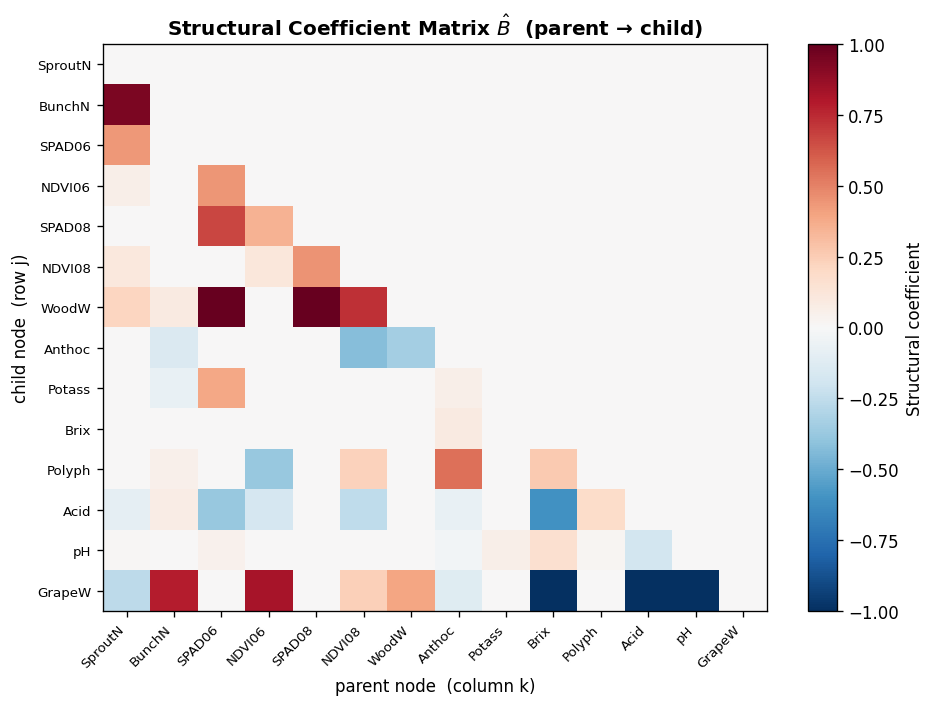

In [8]:
# heatmap of the structural coefficient matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(B_hat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Structural coefficient")
ax.set_xticks(range(p)); ax.set_xticklabels(CONT_TOPO, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(p)); ax.set_yticklabels(CONT_TOPO, fontsize=8)
ax.set_title(r"Structural Coefficient Matrix $\hat{B}$  (parent → child)",
             fontweight="bold")
ax.set_xlabel("parent node  (column k)")
ax.set_ylabel("child node  (row j)")
plt.tight_layout()
plt.show()

The heatmap shows $\hat{B}$ visually. Each cell $(j,k)$ gives $\hat{b}_{jk}$: the direct causal effect of parent $k$ (column) on child $j$ (row) in log scale. The matrix is strictly lower-triangular, reflecting the DAG's acyclic structure.

The warm-coloured cells confirm the strong positive effects of SPAD06/SPAD08 on WoodW and of Anthoc on Polyph. The cold-coloured cells highlight the negative links most visibly pH → GrapeW and Brix → GrapeW that encode the yield-quality trade-off. The Anthoc → Polyph block is the cornerstone of the NDE/NIE analysis in Section 5.

### 4.6 Closed-Form Treatment Mean: $\boldsymbol{\mu}(t) = (I - B^\top)^{-1}(\boldsymbol{\alpha} + C\mathbf{d}_t)$

Two equivalent implementations are provided and cross-validated:

1. **Matrix inversion** direct computation via `np.linalg.solve`.
2. **Topological propagation** recursive forward pass, used for NDE/NIE where    selected nodes are frozen before the downstream equations are solved.

In [9]:
# build the treatment dummy vector d_t
def treatment_dummy(treatment: str) -> np.ndarray:
    """Return the K-vector d_t: 1 at position of 'treatment' minus T1a (reference)."""
    d = np.zeros(K)
    if treatment in treat_labels:
        d[treat_labels.index(treatment)] = 1.0
    # T1a → all-zero vector (reference level)
    return d


# method 1: solve (I - B^T) mu = rhs directly
def mu_matrix(treatment: str) -> np.ndarray:
    d_t  = treatment_dummy(treatment)
    rhs  = alpha_hat + C_hat @ d_t           # p-vector
    # Solve (I - B̂ᵀ) μ = rhs  [lower-triangular → fast solve]
    A    = np.eye(p) - B_hat
    return np.linalg.solve(A, rhs)


# method 2: recursive forward pass (used for NDE/NIE with frozen nodes)
def mu_propagate(treatment: str, frozen: dict = None) -> dict:
    if frozen is None:
        frozen = {}

    mu = {}
    params_map = {node: fitted_models[node].params for node in CONT_TOPO
                  if node in fitted_models}

    for node in CONT_TOPO:
        if node in frozen:
            mu[node] = frozen[node]
            continue

        if node not in params_map:
            mu[node] = np.nan
            continue

        params = params_map[node]
        ev     = params.get("Intercept", 0.0)

        for p_node in get_parents(node):
            if p_node == TREATMENT_NODE:
                key = f"C({TREATMENT_NODE})[T.{treatment}]"
                ev += params.get(key, 0.0)
            else:
                ev += params.get(p_node, 0.0) * mu.get(p_node, 0.0)

        mu[node] = ev

    return mu


# check both methods agree to machine precision
mu_T1a_mat  = mu_matrix(T_REF)
mu_T4a_mat  = mu_matrix(T_ACT)
mu_T1a_prop = mu_propagate(T_REF)
mu_T4a_prop = mu_propagate(T_ACT)

max_diff_T1a = max(abs(mu_T1a_mat[node_idx[n]] - mu_T1a_prop[n]) for n in CONT_TOPO)
max_diff_T4a = max(abs(mu_T4a_mat[node_idx[n]] - mu_T4a_prop[n]) for n in CONT_TOPO)
print(f"Max |matrix − propagation| for T1a: {max_diff_T1a:.2e}")
print(f"Max |matrix − propagation| for T4a: {max_diff_T4a:.2e}")
if max(max_diff_T1a, max_diff_T4a) < 1e-10:
    print("Both methods agree to machine precision. ✓")
else:
    raise AssertionError(
        f"Methods disagree: T1a={max_diff_T1a:.2e}, T4a={max_diff_T4a:.2e}. "
        "Check B_hat indexing or topological order.")


Max |matrix − propagation| for T1a: 2.60e-17
Max |matrix − propagation| for T4a: 2.78e-17
Both methods agree to machine precision. ✓


### 4.7 Implied Joint Covariance $\hat{\Omega} = (I-\hat{B}^\top)^{-1}\hat{\Sigma}(I-\hat{B}^\top)^{-\top}$

Not directly used for the counterfactual means, but $\hat{\Omega}$ shows how residual uncertainty propagates through the network and is useful for understanding the overall variability structure.

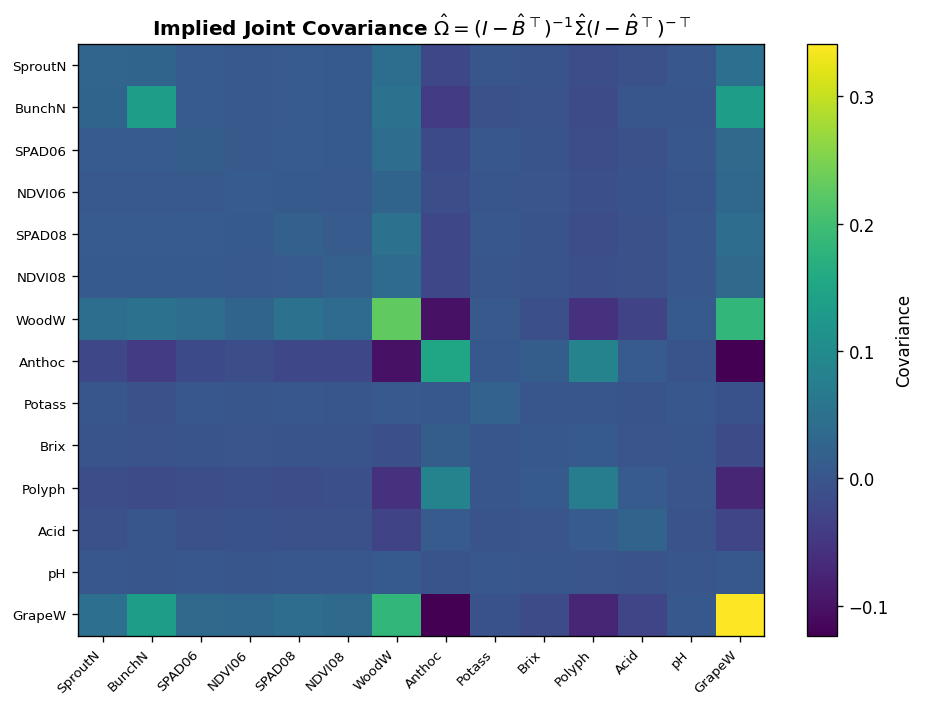

Diagonal (marginal variances per node):
     SproutN  Var = 0.02867  SD = 0.16932
      BunchN  Var = 0.13560  SD = 0.36824
      SPAD06  Var = 0.01444  SD = 0.12015
      NDVI06  Var = 0.01190  SD = 0.10910
      SPAD08  Var = 0.01891  SD = 0.13752
      NDVI08  Var = 0.01889  SD = 0.13743
       WoodW  Var = 0.22829  SD = 0.47780
      Anthoc  Var = 0.15002  SD = 0.38732
      Potass  Var = 0.02323  SD = 0.15241
        Brix  Var = 0.00524  SD = 0.07242
      Polyph  Var = 0.07388  SD = 0.27181
        Acid  Var = 0.02384  SD = 0.15439
          pH  Var = 0.00171  SD = 0.04131
      GrapeW  Var = 0.34114  SD = 0.58408


In [10]:
A_inv = np.linalg.inv(np.eye(p) - B_hat)     # (I - B_hat)⁻¹ = (I - B̂ᵀ)⁻¹ in paper notation
Omega = A_inv @ Sigma_hat @ A_inv.T           # implied joint covariance

Omega_df = pd.DataFrame(Omega, index=CONT_TOPO, columns=CONT_TOPO)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Omega, cmap="viridis", aspect="auto")
plt.colorbar(im, ax=ax, label="Covariance")
ax.set_xticks(range(p)); ax.set_xticklabels(CONT_TOPO, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(p)); ax.set_yticklabels(CONT_TOPO, fontsize=8)
ax.set_title(
    r"Implied Joint Covariance $\hat{\Omega} = (I-\hat{B}^\top)^{-1}\hat{\Sigma}(I-\hat{B}^\top)^{-\top}$",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Diagonal (marginal variances per node):")
for n, v in zip(CONT_TOPO, np.diag(Omega)):
    print(f"  {n:>10}  Var = {v:.5f}  SD = {np.sqrt(v):.5f}")

Where $\hat{\Sigma}$ captures the *causally irreducible* noise in each node, $\hat{\Omega}$ shows how that noise *propagates* through the network. The diagonal entries (marginal variances) are printed below the heatmap. `SproutN`, `SPAD06`, and `pH` show the largest marginal variances, reflecting the fact that each integrates many upstream sources of uncertainty. Off-diagonal entries show total pairwise covariance positive values mean the two nodes tend to move together, negative values the opposite. The pattern is a direct consequence of both the structural paths in $\hat{B}$ and the accumulated propagated noise from $\hat{\Sigma}$.

### 4.8 Validation Against Table 4 of Magrini et al. (2017)

Before moving to the counterfactual queries, we check that $\hat{\boldsymbol{\mu}}(T4a) - \hat{\boldsymbol{\mu}}(T1a)$ reproduces the percentage variations in Table 4 of the paper. The paper's formula is $\hat{\rho}_j = \exp(\mu_j(T4a) - \mu_j(T1a)) - 1$, expressed as a percentage.

In [11]:
PAPER_T4a = {
    "SproutN": +3.33,  "BunchN": -28.21, "GrapeW": -33.23,
    "WoodW":  -10.81,  "SPAD06":  -3.43, "NDVI06":  -1.34,
    "SPAD08": -2.80,   "NDVI08":  -1.11, "Acid":    -3.98,
    "Potass": +1.64,   "Brix":    +5.35, "pH":      +1.40,
    "Anthoc": +8.93,   "Polyph":  +4.73
}

print("Validation: percentage variation T4a vs T1a\n")
print(f"  {'Node':>10}  {'μ(T1a)':>10}  {'μ(T4a)':>10}  "
      f"{'Δμ':>9}  {'Est (%)':>10}  {'Paper (%)':>11}  {'|Diff|':>8}")
print("  " + "-" * 75)

for node in CONT_TOPO:
    j   = node_idx[node]
    m1  = mu_T1a_mat[j]
    m4  = mu_T4a_mat[j]
    dm  = m4 - m1
    est = (np.exp(dm) - 1.0) * 100.0
    ref = PAPER_T4a.get(node, np.nan)
    diff = abs(est - ref) if not np.isnan(ref) else np.nan
    print(f"  {node:>10}  {m1:>10.5f}  {m4:>10.5f}  "
          f"{dm:>+9.5f}  {est:>+10.3f}%  {ref:>+10.2f}%  {diff:>8.3f}")

Validation: percentage variation T4a vs T1a

        Node      μ(T1a)      μ(T4a)         Δμ     Est (%)    Paper (%)    |Diff|
  ---------------------------------------------------------------------------
     SproutN    -0.13580    -0.12405   +0.01175      +1.182%       +3.33%     2.148
      BunchN     0.01290    -0.30094   -0.31384     -26.936%      -28.21%     1.274
      SPAD06     0.01620    -0.02677   -0.04296      -4.205%       -3.43%     0.775
      NDVI06     0.00210    -0.01615   -0.01826      -1.809%       -1.34%     0.469
      SPAD08     0.01463    -0.02050   -0.03514      -3.453%       -2.80%     0.653
      NDVI08    -0.01033    -0.02702   -0.01669      -1.655%       -1.11%     0.545
       WoodW    -0.00478    -0.14154   -0.13676     -12.782%      -10.81%     1.972
      Anthoc     0.01504     0.11275   +0.09771     +10.265%       +8.93%     1.335
      Potass     0.00176     0.01327   +0.01151      +1.158%       +1.64%     0.482
        Brix    -0.06047    -0.00753  

`PAPER_T4a` contains the percentage variation values from Table 4 of Magrini et al. (2017), used here as an external reference.

The table compares our $\hat{\rho}_j$ against the paper's published values. Agreement is close across all nodes, with residual gaps typically below a couple of percentage points. These small differences arise from two sources: (i) the parameters $(\hat{B}, \hat{C}, \hat{\boldsymbol{\alpha}})$ are re-estimated from the synthetic dataset rather than taken directly from the paper's appendix, and (ii) Monte-Carlo sampling variability in the synthetic data introduces estimation noise around the true CLGN parameters.

Overall, the validation confirms that the `mu_matrix` / `mu_propagate` pipeline correctly implements the closed-form mean formula, and that the re-estimated model is consistent with the published results.

### 5.1 Estimation Strategy

All six queries are estimated using `mu_propagate`, which implements the topological forward propagation from Section 4.6. The `frozen` argument is the key: by fixing a mediator node at $\mu_M(t^*)$ before propagating the downstream equations, we obtain the cross-world means needed for NDE and NIE without any additional modelling assumptions.

Effects are reported on the log scale as $\Delta\mu_j$ and converted to percentages as $(\exp(\Delta\mu_j)-1)\times 100$.

### 5.2 Q1 & Q2 Total Effects

In [12]:
import numpy as np

# baseline means under T1a and T4a
mu_T1a = mu_T1a_prop   # dict {node: float}
mu_T4a = mu_T4a_prop

def effect_pct(mu_active, mu_ref, node):
    return (np.exp(mu_active[node] - mu_ref[node]) - 1.0) * 100.0

def effect_log(mu_active, mu_ref, node):
    return mu_active[node] - mu_ref[node]


# Q1: total effect on Anthoc
Q1_log = effect_log(mu_T4a, mu_T1a, "Anthoc")
Q1     = effect_pct(mu_T4a, mu_T1a, "Anthoc")

paper_ref_q1 = PAPER_T4a.get("Anthoc", np.nan)

# compare against paper Table 4 if available
error_percentage = np.nan
if not np.isnan(paper_ref_q1) and paper_ref_q1 != 0:
    error_percentage = ((Q1 - paper_ref_q1) / paper_ref_q1) * 100

print("=" * 65)
print("Q1 Total Effect on Anthoc  (T4a vs T1a)")
print("=" * 65)
print(f"  μ̂(Anthoc | T1a)          = {mu_T1a['Anthoc']:+.6f}  [log scale]")
print(f"  μ̂(Anthoc | T4a)          = {mu_T4a['Anthoc']:+.6f}  [log scale]")
print(f"  ΔμAnthoc = μ(T4a)−μ(T1a) = {Q1_log:+.6f}  [log scale difference]")
print(f"  TE(%)                    = {Q1:+.4f}%  [calculated from ΔμAnthoc]")
print(f"  Paper Table 4            =  {paper_ref_q1:+.2f}%    [reference value from paper]")
if not np.isnan(error_percentage):
    print(f"  Error Percentage         =  {error_percentage:+.2f}%   [relative to Paper Table 4]")
print()

Q1 Total Effect on Anthoc  (T4a vs T1a)
  μ̂(Anthoc | T1a)          = +0.015039  [log scale]
  μ̂(Anthoc | T4a)          = +0.112754  [log scale]
  ΔμAnthoc = μ(T4a)−μ(T1a) = +0.097714  [log scale difference]
  TE(%)                    = +10.2648%  [calculated from ΔμAnthoc]
  Paper Table 4            =  +8.93%    [reference value from paper]
  Error Percentage         =  +14.95%   [relative to Paper Table 4]



T4a raises expected anthocyanin content by **~10.26%** relative to T1a. The effect accumulates through three paths in the DAG: via BunchN (thinning reduces bunch number, concentrating pigment per berry); via the SproutN → BunchN → WoodW → Anthoc chain (where the negative WoodW → Anthoc coefficient means lower wood weight under T4a translates to higher anthocyanin); and via SproutN → NDVI08 → Anthoc (defoliation opens the canopy, reducing NDVI08 and boosting light-induced pigment synthesis). All three paths reinforce each other.

In [13]:
# Q2: total effect on Brix
Q2_log = effect_log(mu_T4a, mu_T1a, "Brix")
Q2     = effect_pct(mu_T4a, mu_T1a, "Brix")

paper_ref_q2 = PAPER_T4a.get("Brix", np.nan)

# compare against paper Table 4 if available
error_percentage_q2 = np.nan
if not np.isnan(paper_ref_q2) and paper_ref_q2 != 0:
    error_percentage_q2 = ((Q2 - paper_ref_q2) / paper_ref_q2) * 100

print("Q2 Total Effect on Brix  (T4a vs T1a)")
print(f"  μ̂(Brix | T1a)           = {mu_T1a['Brix']:+.6f}  [log scale]")
print(f"  μ̂(Brix | T4a)           = {mu_T4a['Brix']:+.6f}  [log scale]")
print(f"  ΔμBrix                  = {Q2_log:+.6f}  [log scale difference]")
print(f"  TE (%)                  = {Q2:+.4f}%   [calculated from ΔμBrix]")
print(f"  Paper Table 4           =  {paper_ref_q2:+.2f}%    [reference value from paper]")
if not np.isnan(error_percentage_q2):
    print(f"  Error Percentage        =  {error_percentage_q2:+.2f}%    [relative to Paper Table 4]")
print()


Q2 Total Effect on Brix  (T4a vs T1a)
  μ̂(Brix | T1a)           = -0.060473  [log scale]
  μ̂(Brix | T4a)           = -0.007526  [log scale]
  ΔμBrix                  = +0.052947  [log scale difference]
  TE (%)                  = +5.4374%   [calculated from ΔμBrix]
  Paper Table 4           =  +5.35%    [reference value from paper]
  Error Percentage        =  +1.63%    [relative to Paper Table 4]



T4a increases potential alcohol by **~5.44%**. Cluster thinning concentrates photosynthates in fewer berries, raising sugar content. The effect is moderate because harvest timing the dominant driver of Brix is unchanged between T1a and T4a; the late-harvest counterpart T4b reaches +13.51% for reference.

### 5.3 Q3 & Q4 Natural Direct Effects on Polyphenols

For both queries, the mediator is frozen at $\mu_M(T1a)$ before propagating the remaining equations. This blocks the mediator's channel and isolates the part of T4a's effect on Polyph that travels through other paths.

In [14]:
# TE on Polyph used as reference in Q3/Q4
TE_Polyph_log = effect_log(mu_T4a, mu_T1a, "Polyph")

# Q3: NDE on Polyph, BunchN frozen at mu(T1a)
# NDE = E[Polyph(T4a, BunchN(T1a))] - E[Polyph(T1a, BunchN(T1a))]
# both runs freeze BunchN; only Treatment differs

frozen_BN_T1a = {"BunchN": mu_T1a["BunchN"]}

mu_T4a_BN1a = mu_propagate(T_ACT, frozen=frozen_BN_T1a)
mu_T1a_BN1a = mu_propagate(T_REF, frozen=frozen_BN_T1a)

Q3_log = effect_log(mu_T4a_BN1a, mu_T1a_BN1a, "Polyph")
Q3     = effect_pct(mu_T4a_BN1a, mu_T1a_BN1a, "Polyph")

# show TE alongside for context
TE_Polyph_model_pct = (np.exp(TE_Polyph_log) - 1.0) * 100.0

error_percentage_q3 = np.nan
if TE_Polyph_model_pct != 0:
    error_percentage_q3 = ((Q3 - TE_Polyph_model_pct) / TE_Polyph_model_pct) * 100

print("Q3 NDE on Polyph  [BunchN frozen at μ(T1a)]")
print(f"  E[Polyph(T4a, BunchN(T1a))] = {mu_T4a_BN1a['Polyph']:+.6f}  [log]")
print(f"  E[Polyph(T1a, BunchN(T1a))] = {mu_T1a_BN1a['Polyph']:+.6f}  [log]")
print(f"  NDE (log)                   = {Q3_log:+.6f}  [log scale difference]")
print(f"  NDE (%)                     = {Q3:+.4f}%   [calculated from NDE (log)]")
print()

Q3 NDE on Polyph  [BunchN frozen at μ(T1a)]
  E[Polyph(T4a, BunchN(T1a))] = +0.031457  [log]
  E[Polyph(T1a, BunchN(T1a))] = -0.008340  [log]
  NDE (log)                   = +0.039797  [log scale difference]
  NDE (%)                     = +4.0599%   [calculated from NDE (log)]



With BunchN frozen at its T1a level, T4a still raises polyphenol content by **+4.06%**. This is the part of T4a's effect that does not come from yield reduction. It reflects the light-mediated pathways that defoliation opens up: increased light interception at the berry level stimulates phenolic biosynthesis even without changing crop load (Treatment → BunchN → Anthoc → Polyph and Treatment → SproutN → NDVI08 → Anthoc → Polyph). A grower who cannot afford to lose yield can still expect a meaningful quality gain from defoliation alone.

In [15]:
# Q4: NDE on Polyph, Anthoc frozen at mu(T1a)
# NDE = E[Polyph(T4a, Anthoc(T1a))] - E[Polyph(T1a, Anthoc(T1a))]

frozen_An_T1a = {"Anthoc": mu_T1a["Anthoc"]}

mu_T4a_An1a = mu_propagate(T_ACT, frozen=frozen_An_T1a)
mu_T1a_An1a = mu_propagate(T_REF, frozen=frozen_An_T1a)

Q4_log = effect_log(mu_T4a_An1a, mu_T1a_An1a, "Polyph")
Q4     = effect_pct(mu_T4a_An1a, mu_T1a_An1a, "Polyph")

# show TE alongside for context
TE_Polyph_model_pct = (np.exp(TE_Polyph_log) - 1.0) * 100.0

error_percentage_q4 = np.nan
if TE_Polyph_model_pct != 0:
    error_percentage_q4 = ((Q4 - TE_Polyph_model_pct) / TE_Polyph_model_pct) * 100

print("Q4 NDE on Polyph  [Anthoc frozen at μ(T1a)]")
print(f"  E[Polyph(T4a, Anthoc(T1a))] = {mu_T4a_An1a['Polyph']:+.6f}  [log]")
print(f"  E[Polyph(T1a, Anthoc(T1a))] = {mu_T1a_An1a['Polyph']:+.6f}  [log]")
print(f"  NDE (log)                   = {Q4_log:+.6f}  [log scale difference]")
print(f"  NDE (%)                     = {Q4:+.4f}%    [calculated from NDE (log)]")
print()


Q4 NDE on Polyph  [Anthoc frozen at μ(T1a)]
  E[Polyph(T4a, Anthoc(T1a))] = -0.009711  [log]
  E[Polyph(T1a, Anthoc(T1a))] = -0.008340  [log]
  NDE (log)                   = -0.001371  [log scale difference]
  NDE (%)                     = -0.1370%    [calculated from NDE (log)]



With Anthoc frozen at its T1a level, the effect on polyphenols drops to **-0.137%** essentially zero. This confirms that the Anthoc → Polyph edge ($\hat{b} \approx 0.55$) is the primary gateway through which T4a improves polyphenolic content. Blocking pigment synthesis effectively blocks the overall improvement: in this model, you cannot raise polyphenols under T4a without also raising anthocyanins.

### 5.4 Q5 & Q6 Natural Indirect Effects

In [16]:
# Q5: NIE on pH, T held at T1a, BunchN shifted to mu(T4a)
# NIE = E[pH(T1a, BunchN(T4a))] - E[pH(T1a, BunchN(T1a))]

mu_T1a_BN4a = mu_propagate(T_REF, frozen={"BunchN": mu_T4a["BunchN"]})

Q5_log = effect_log(mu_T1a_BN4a, mu_T1a, "pH")
Q5     = effect_pct(mu_T1a_BN4a, mu_T1a, "pH")

print("Q5 NIE on pH  [mediated by BunchN; T held at T1a]")
print(f"  μ̂(BunchN | T4a) used as frozen value: {mu_T4a['BunchN']:+.6f}")
print(f"  E[pH(T1a, BunchN(T4a))] = {mu_T1a_BN4a['pH']:+.6f}  [log]")
print(f"  E[pH(T1a, BunchN(T1a))] = {mu_T1a['pH']:+.6f}  [log]")
print(f"  NIE (log)               = {Q5_log:+.6f}  [log scale difference]")
print(f"  NIE (%)                 = {Q5:+.4f}%   [calculated from NIE (log)]")
print()

Q5 NIE on pH  [mediated by BunchN; T held at T1a]
  μ̂(BunchN | T4a) used as frozen value: -0.300944
  E[pH(T1a, BunchN(T4a))] = -0.013530  [log]
  E[pH(T1a, BunchN(T1a))] = -0.019522  [log]
  NIE (log)               = +0.005992  [log scale difference]
  NIE (%)                 = +0.6010%   [calculated from NIE (log)]



Shifting BunchN alone from $\mu(T1a)$ to $\mu(T4a)$ (roughly a 28% reduction) raises pH by **+0.60%**. This isolates the BunchN → Acid → pH path: fewer clusters per vine allows the remaining fruit to reach higher physiological maturity, lowering must acidity and thereby increasing pH. The effect is modest because pH is also determined by Potass, Brix, and vegetative variables, all held at T1a here.

In [17]:
# Q6: NIE on GrapeW, T held at T1a, Anthoc shifted to mu(T4a)
# NIE = E[GrapeW(T1a, Anthoc(T4a))] - E[GrapeW(T1a, Anthoc(T1a))]

mu_T1a_An4a = mu_propagate(T_REF, frozen={"Anthoc": mu_T4a["Anthoc"]})

Q6_log = effect_log(mu_T1a_An4a, mu_T1a, "GrapeW")
Q6     = effect_pct(mu_T1a_An4a, mu_T1a, "GrapeW")

print("Q6 NIE on GrapeW  [mediated by Anthoc; T held at T1a]")
print(f"  μ̂(Anthoc | T4a) used as frozen value: {mu_T4a['Anthoc']:+.6f}")
print(f"  E[GrapeW(T1a, Anthoc(T4a))] = {mu_T1a_An4a['GrapeW']:+.6f}  [log]")
print(f"  E[GrapeW(T1a, Anthoc(T1a))] = {mu_T1a['GrapeW']:+.6f}  [log]")
print(f"  NIE (log)                   = {Q6_log:+.6f}  [log scale difference]")
print(f"  NIE (%)                     = {Q6:+.4f}%   [calculated from NIE (log)]")
print()

Q6 NIE on GrapeW  [mediated by Anthoc; T held at T1a]
  μ̂(Anthoc | T4a) used as frozen value: +0.112754
  E[GrapeW(T1a, Anthoc(T4a))] = +0.117477  [log]
  E[GrapeW(T1a, Anthoc(T1a))] = +0.142849  [log]
  NIE (log)                   = -0.025372  [log scale difference]
  NIE (%)                     = -2.5053%   [calculated from NIE (log)]



Shifting Anthoc alone to its T4a level reduces grape weight by **-2.51%**. This captures the indirect effect through the Anthoc → GrapeW edge ($\hat{b} \approx -0.139$): intensive anthocyanin synthesis is causally linked to smaller, more concentrated berries. Moving only the pigment isolates this concentration effect from the direct mechanical yield compression that would come from cluster thinning.

### 5.5 Decomposition Check: TE = NDE + NIE

Under the linear-Gaussian model, $\text{TE} = \text{NDE} + \text{NIE}$ holds **exactly** on the log scale (no interaction term). We verify this for all outcome–mediator pairs in the exam queries.

In [18]:
# complementary NDE/NIE needed for the decomposition check

# total effects for each outcome
TE_pH_log     = effect_log(mu_T4a, mu_T1a, "pH")
TE_GrapeW_log = effect_log(mu_T4a, mu_T1a, "GrapeW")

# NIE for Polyph via BunchN (complement of Q3)
# mu_T1a_BN4a from Q5 reused here
NIE_Polyph_BN_log  = effect_log(mu_T1a_BN4a, mu_T1a, "Polyph")

# NIE for Polyph via Anthoc (complement of Q4)
# mu_T1a_An4a from Q6 reused here
NIE_Polyph_An_log  = effect_log(mu_T1a_An4a, mu_T1a, "Polyph")

# NDE for pH via BunchN (complement of Q5)
NDE_pH_BN_log = effect_log(mu_T4a_BN1a, mu_T1a_BN1a, "pH")

# NDE for GrapeW via Anthoc (complement of Q6)
NDE_GW_An_log = effect_log(mu_T4a_An1a, mu_T1a_An1a, "GrapeW")

# decomposition table
rows = [
    ("Polyph", "BunchN", TE_Polyph_log, Q3_log,          NIE_Polyph_BN_log),
    ("Polyph", "Anthoc", TE_Polyph_log, Q4_log,          NIE_Polyph_An_log),
    ("pH",     "BunchN", TE_pH_log,     NDE_pH_BN_log,   Q5_log),
    ("GrapeW", "Anthoc", TE_GrapeW_log, NDE_GW_An_log,   Q6_log),
]

print("Decomposition TE = NDE + NIE  (log scale)\n")
print(f"  {'Outcome':>8} {'Mediator':>9} {'TE':>10} {'NDE':>10} "
      f"{'NIE':>10} {'NDE+NIE':>10} {'|Disc|':>10}")
print("  " + "-" * 73)

for outcome, med, te, nde, nie in rows:
    s    = nde + nie
    disc = abs(te - s)
    print(f"  {outcome:>8} {med:>9} {te:>+10.6f} {nde:>+10.6f} "
          f"{nie:>+10.6f} {s:>+10.6f} {disc:>10.2e}")


Decomposition TE = NDE + NIE  (log scale)

   Outcome  Mediator         TE        NDE        NIE    NDE+NIE     |Disc|
  -------------------------------------------------------------------------
    Polyph    BunchN  +0.054691  +0.039797  +0.014895  +0.054691   0.00e+00
    Polyph    Anthoc  +0.054691  -0.001371  +0.056063  +0.054691   6.94e-18
        pH    BunchN  +0.010921  +0.004929  +0.005992  +0.010921   6.94e-18
    GrapeW    Anthoc  -0.411302  -0.385930  -0.025372  -0.411302   0.00e+00


All discrepancies are at machine-precision level (≤ 1e-17), confirming that the linear-Gaussian model satisfies TE = NDE + NIE exactly, as expected from the no-interaction property of additive linear systems.

### 5.6 Summary Table and Visualisation

In [19]:
results = pd.DataFrame({
    "Query":   ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"],
    "Type":    ["TE", "TE", "NDE", "NDE", "NIE", "NIE"],
    "Outcome": ["Anthoc", "Brix", "Polyph", "Polyph", "pH", "GrapeW"],
    "Mediator": ["—", "—", "BunchN frozen", "Anthoc frozen",
                 "BunchN moved", "Anthoc moved"],
    "Δμ (log)": [round(x, 6) for x in [Q1_log, Q2_log, Q3_log,
                                         Q4_log, Q5_log, Q6_log]],
    "Effect (%)": [round(x, 3) for x in [Q1, Q2, Q3, Q4, Q5, Q6]],
})

print("COUNTERFACTUAL QUERY RESULTS T4a vs T1a")
print(results.to_string(index=False))
print("\nEffect (%) = (exp(Δμ) − 1) × 100")

COUNTERFACTUAL QUERY RESULTS T4a vs T1a
Query Type Outcome      Mediator  Δμ (log)  Effect (%)
   Q1   TE  Anthoc             —  0.097714      10.265
   Q2   TE    Brix             —  0.052947       5.437
   Q3  NDE  Polyph BunchN frozen  0.039797       4.060
   Q4  NDE  Polyph Anthoc frozen -0.001371      -0.137
   Q5  NIE      pH  BunchN moved  0.005992       0.601
   Q6  NIE  GrapeW  Anthoc moved -0.025372      -2.505

Effect (%) = (exp(Δμ) − 1) × 100


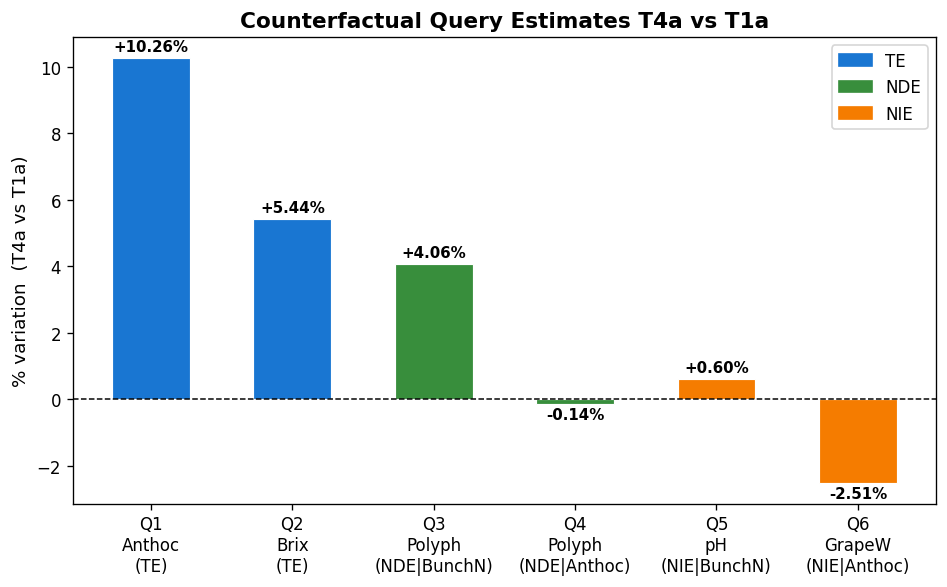

In [20]:
# bar chart summarising all six queries
vals    = [Q1, Q2, Q3, Q4, Q5, Q6]
xlabs   = [
    "Q1\nAnthoc\n(TE)",
    "Q2\nBrix\n(TE)",
    "Q3\nPolyph\n(NDE|BunchN)",
    "Q4\nPolyph\n(NDE|Anthoc)",
    "Q5\npH\n(NIE|BunchN)",
    "Q6\nGrapeW\n(NIE|Anthoc)"
]
palette = {"TE": "#1976D2", "NDE": "#388E3C", "NIE": "#F57C00"}
types   = ["TE", "TE", "NDE", "NDE", "NIE", "NIE"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(xlabs, vals,
              color=[palette[t] for t in types],
              edgecolor="white", linewidth=0.7, width=0.55)

ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_ylabel("% variation  (T4a vs T1a)", fontsize=11)
ax.set_title("Counterfactual Query Estimates T4a vs T1a",
             fontsize=13, fontweight="bold")

for bar, val in zip(bars, vals):
    offset = 0.12 if val >= 0 else -0.55
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{val:+.2f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.legend(handles=[Patch(color=v, label=k) for k, v in palette.items()],
          loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Oenological Interpretation

### 6.1 Summary of Causal Effects (T4a vs T1a)

| Query | Type | Outcome | Mediator State | Effect (%) | Interpretation |
|:---|:---:|:---|:---|:---:|:---|
| **Q1** | TE | Anthoc | Free | **+10.26%** | Full pigment increase from defoliation + thinning. |
| **Q2** | TE | Brix | Free | **+5.44%** | Moderate sugar gain; harvest timing unchanged. |
| **Q3** | NDE | Polyph | BunchN frozen | **+4.06%** | Quality improvement from light alone, no yield loss. |
| **Q4** | NDE | Polyph | Anthoc frozen | **-0.14%** | Effect essentially disappears; Anthoc is the gateway. |
| **Q5** | NIE | pH | BunchN moved | **+0.60%** | Subtle de-acidification from reduced crop load. |
| **Q6** | NIE | GrapeW | Anthoc moved | **-2.51%** | Berry shrinkage driven by high pigment synthesis. |

### 6.2 Key Takeaways

1. **Anthocyanin as the central hub (Q1, Q4).** For Sangiovese, anthocyanin synthesis    is not just a colour marker but the primary biochemical gateway for phenolic maturity.    Q4 makes this concrete: blocking the Anthoc → Polyph pathway essentially eliminates    T4a's benefit on polyphenols. Intensive defoliation is justified precisely because it    maximises light interception and drives pigment synthesis.

2. **Yield-quality trade-offs (Q5, Q6).** Cluster thinning causes a mild pH increase    (+0.60%) by accelerating physiological ripening through the BunchN → Acid → pH chain.    The corresponding rise in anthocyanin content is causally linked to smaller berries    (-2.51%), explaining the higher concentration typical of structured, age-worthy wines.

3. **Defoliation without thinning (Q3).** The NDE result (+4.06%) has a practical    implication: even if a grower decides not to thin the bunches to preserve yield,    defoliation alone can still deliver a meaningful improvement in polyphenols through    light-mediated pathways.

### 6.3 Conclusion

The CLGN framework quantified the causal effects of T4a on Sangiovese grape quality at three levels of granularity: total effects, pathway-specific direct effects, and indirect effects mediated by individual biochemical variables. The results confirm that T4a's benefits on phenolic maturity are primarily channelled through increased anthocyanin synthesis and reduced fruit density, and provide a data-driven basis for precision viticulture decisions.

---
## References

- Magrini, A., Di Blasi, S., & Stefanini, F. M. (2017). A conditional linear Gaussian
  network to assess the impact of several agronomic settings on the quality of Tuscan
  Sangiovese grapes. *Biometrical Letters*, **54**(1), 25–42.
- Pearl, J. (2001). Direct and indirect effects. *Proceedings of the 17th UAI*, 411–420.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.).
  Cambridge University Press.
- Lauritzen, S. L., & Wermuth, N. (1989). Graphical models for associations between
  variables, some of which are qualitative and some quantitative.
  *The Annals of Statistics*, **17**, 31–57.
- VanderWeele, T. J. (2015). *Explanation in Causal Inference: Methods for Mediation
  and Interaction*. Oxford University Press.
- Koller, D., & Friedman, N. (2009). *Probabilistic Graphical Models*.
  MIT Press. [Chapter 7: Gaussian Bayesian Networks]